# Week 7 – Alert Generation and Logging

Objective:
- Simulate real-time intrusion detection
- Generate alerts for detected attacks
- Analyze alert behavior and system performance
- Store results in structured log files

In [1]:
import joblib
import numpy as np
import pandas as pd
import os
from datetime import datetime

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
model = joblib.load("models/best_model.pkl")
preprocessor = joblib.load("models/preprocessor.pkl")

In [3]:
COLUMNS = [
'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
'wrong_fragment','urgent','hot','num_failed_logins','logged_in',
'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
'num_shells','num_access_files','num_outbound_cmds','is_host_login',
'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
'dst_host_same_srv_rate','dst_host_diff_srv_rate',
'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
'dst_host_serror_rate','dst_host_srv_serror_rate',
'dst_host_rerror_rate','dst_host_srv_rerror_rate','class','difficulty_level'
]

df = pd.read_csv("data/KDDTrain+.txt", names=COLUMNS)

df['binary_class'] = df['class'].apply(lambda x: 0 if x == 'normal' else 1)

X = df.drop(['class','binary_class','difficulty_level'], axis=1)
y = df['binary_class']

In [4]:
X_processed = preprocessor.transform(X)

print("Processed Data Shape:", X_processed.shape)

Processed Data Shape: (125973, 121)


In [5]:
def get_severity(prob):
    if prob > 0.9:
        return "High"
    elif prob > 0.7:
        return "Medium"
    else:
        return "Low"

In [6]:
alerts = []

for i in range(len(X_processed)):
    
    sample = X_processed[i].reshape(1, -1)
    
    pred = model.predict(sample)[0]
    
    if pred == 1:
        prob = model.predict_proba(sample)[0][1]
        severity = get_severity(prob)
        
        alerts.append({
            "Index": i,
            "Alert": "Intrusion Detected",
            "Confidence": round(prob, 3),
            "Severity": severity,
            "Timestamp": datetime.now()
        })

In [7]:
alert_df = pd.DataFrame(alerts)

print("Total Alerts Generated:", len(alert_df))

Total Alerts Generated: 58286


In [8]:
alert_df.sort_values(by="Confidence", ascending=False, inplace=True)

In [9]:
os.makedirs("logs", exist_ok=True)

alert_df.to_csv("logs/intrusion_alerts.csv", index=False)

print("Logs saved successfully!")

Logs saved successfully!


In [10]:
alert_df.head()

,Index,Alert,Confidence,Severity,Timestamp
58285,125971,Intrusion Detected,1.0,High,2026-03-30 19:14:51.668326
0,2,Intrusion Detected,1.0,High,2026-03-30 19:03:54.663415
1,5,Intrusion Detected,1.0,High,2026-03-30 19:03:54.687310
2,6,Intrusion Detected,1.0,High,2026-03-30 19:03:54.699429
3,7,Intrusion Detected,1.0,High,2026-03-30 19:03:54.708875


In [11]:
print("\nSeverity Distribution:")
print(alert_df["Severity"].value_counts())


Severity Distribution:
Severity
High      55534
Medium     2051
Low         701
Name: count, dtype: int64


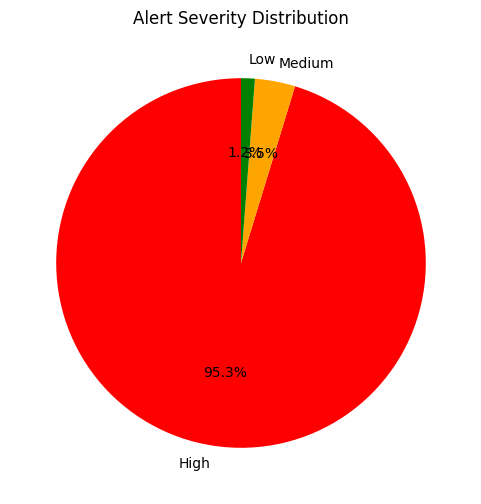

In [19]:
plt.figure(figsize=(6,6))

colors = ['red', 'orange', 'green']

plt.pie(
    severity_counts,
    labels=severity_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)

plt.title("Alert Severity Distribution")

plt.show()

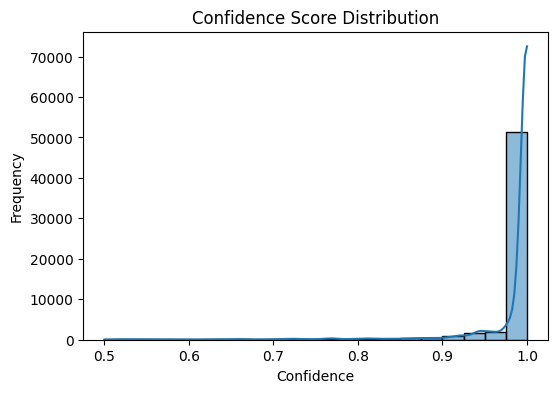

In [20]:
plt.figure(figsize=(6,4))

sns.histplot(alert_df["Confidence"], bins=20, kde=True)

plt.title("Confidence Score Distribution")
plt.xlabel("Confidence")
plt.ylabel("Frequency")

plt.show()

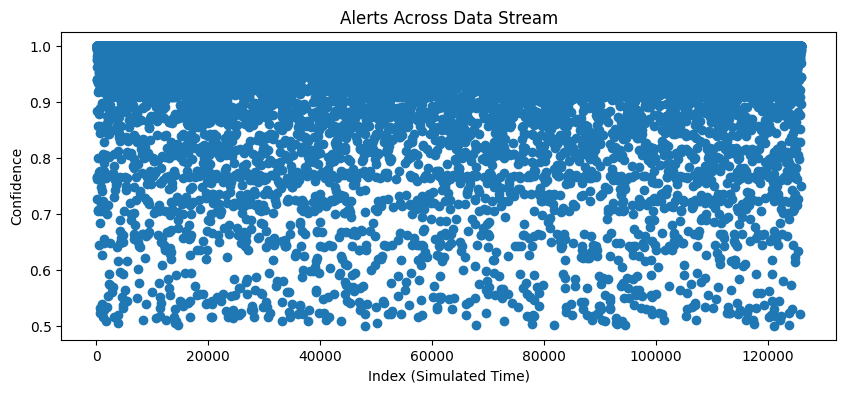

In [21]:
plt.figure(figsize=(10,4))

plt.plot(alert_df["Index"], alert_df["Confidence"], 'o')

plt.title("Alerts Across Data Stream")
plt.xlabel("Index (Simulated Time)")
plt.ylabel("Confidence")

plt.show()


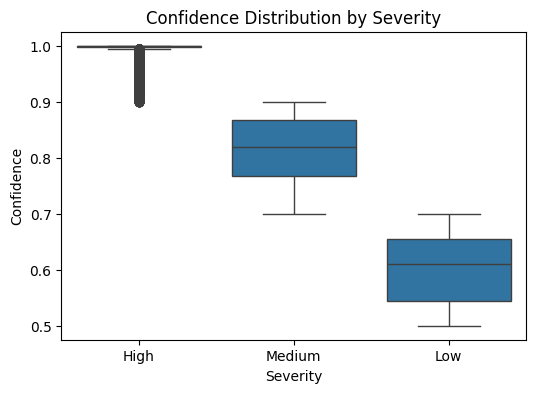

In [22]:
plt.figure(figsize=(6,4))

sns.boxplot(x="Severity", y="Confidence", data=alert_df)

plt.title("Confidence Distribution by Severity")

plt.show()

In [12]:
alert_rate = len(alert_df) / len(X_processed)

print("Alert Rate:", round(alert_rate * 100, 2), "%")

Alert Rate: 46.27 %


In [13]:
detected_indices = set(alert_df["Index"])

total_attacks = sum(y == 1)
detected_attacks = sum(i in detected_indices for i in range(len(y)) if y.iloc[i] == 1)

print("Total Actual Attacks:", total_attacks)
print("Detected Attacks:", detected_attacks)

print("Detection Rate:", round((detected_attacks / total_attacks) * 100, 2), "%")

Total Actual Attacks: 58630
Detected Attacks: 58226
Detection Rate: 99.31 %


In [14]:
false_alarms = sum(i in detected_indices for i in range(len(y)) if y.iloc[i] == 0)

print("False Alarms:", false_alarms)

False Alarms: 60


In [15]:
summary = {
    "Total Samples": len(X_processed),
    "Total Alerts": len(alert_df),
    "High Severity": sum(alert_df["Severity"] == "High"),
    "Medium Severity": sum(alert_df["Severity"] == "Medium"),
    "Low Severity": sum(alert_df["Severity"] == "Low")
}

summary

{'Total Samples': 125973,
 'Total Alerts': 58286,
 'High Severity': 55534,
 'Medium Severity': 2051,
 'Low Severity': 701}

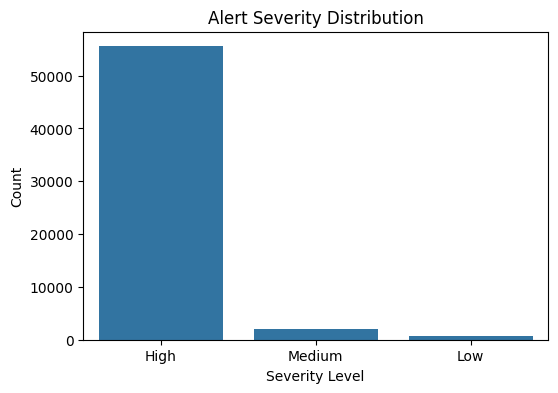

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(x="Severity", data=alert_df)

plt.title("Alert Severity Distribution")
plt.xlabel("Severity Level")
plt.ylabel("Count")

plt.show()

In [17]:
top_alerts = alert_df.head(5)

top_alerts

,Index,Alert,Confidence,Severity,Timestamp
58285,125971,Intrusion Detected,1.0,High,2026-03-30 19:14:51.668326
0,2,Intrusion Detected,1.0,High,2026-03-30 19:03:54.663415
1,5,Intrusion Detected,1.0,High,2026-03-30 19:03:54.687310
2,6,Intrusion Detected,1.0,High,2026-03-30 19:03:54.699429
3,7,Intrusion Detected,1.0,High,2026-03-30 19:03:54.708875


## Conclusion

- The trained model was used to simulate intrusion detection.
- Alerts were generated for detected intrusions with confidence scores.
- Alerts were categorized into severity levels.
- Detection rate and false alarm analysis were performed.
- Results were stored in structured log files for monitoring.
- This demonstrates a practical intrusion detection system pipeline.